In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import seaborn as sns
from matplotlib import pyplot as plt
from alphaanalysis.plot.gam import get_sig_intervals
import utils

# Data Base

In [3]:
from djimaging.user.alpha.utils import access_database

indicator = 'calcium'

database = access_database.access_database(indicator, use_sql=False)
df = database.get_tri_df()
df = df.drop(columns=['chirp_avg', 'trf'])

Loading calcium data from: /gpfs01/berens/user/joesterle/projects/alpha/__public_s-on-alpha-regional/gnode/s-on-alpha-regional/database-exports/Ran/sONa_calcium


# Plot

In [4]:
from alphaanalysis import plot as plota
plota.set_rc_params()

In [5]:
order = plota.get_order(indicator=indicator)
palette = plota.get_palette(indicator=indicator)
colors = [palette[group] for group in order]

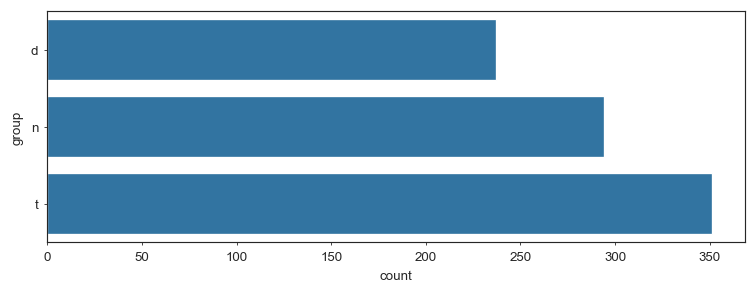

In [6]:
sns.countplot(data=df, y="group");

# Fit GAM

In [7]:
%load_ext rpy2.ipython

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 


In [8]:
%%R

rm(list=ls()) 

In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library '/usr/lib/R/site-library' contains no packages


## R imports

In [9]:
#!sudo apt-get update
#!sudo apt-get install -y libfontconfig1-dev
# !sudo apt-get install -y libcairo2-dev

In [10]:
#!sudo Rscript -e 'install.packages("IRdisplay")'
#!sudo Rscript -e 'install.packages("dplyr")'
#!sudo Rscript -e 'install.packages("parallel")'
#!sudo Rscript -e 'install.packages("ggplot2")'
#!sudo Rscript -e 'install.packages("nlme")'
#!sudo Rscript -e 'install.packages("mgcv")'
#!sudo Rscript -e 'install.packages("hrbrthemes")'
#!sudo Rscript -e 'install.packages("ggthemes")'
#!sudo Rscript -e 'install.packages("itsadug")'
#!sudo Rscript -e 'install.packages("png")'
#!sudo Rscript -e 'install.packages("xtable")'
#!sudo Rscript -e 'install.packages("tidymv")'
#!sudo Rscript -e 'install.packages("cowplot")'

In [11]:
%%R

library("IRdisplay")
library("dplyr")
library('parallel')
library('ggplot2')
library("nlme")
library("mgcv")
# library("hrbrthemes")
library("ggthemes")
library("itsadug")
library("png")
library("xtable")
library("tidymv")
library("cowplot")


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Attaching package: 'nlme'

The following object is masked from 'package:dplyr':

    collapse

This is mgcv 1.9-0. For overview type 'help("mgcv-package")'.
Loading required package: plotfunctions

Attaching package: 'plotfunctions'

The following object is masked from 'package:ggplot2':

    alpha

Loaded package itsadug 2.4 (see 'help("itsadug")' ).

Attaching package: 'xtable'

The following object is masked from 'package:IRdisplay':

    display

tidymv has been superseded by tidygam. The package tidymv is no longer maintained but will be
    kept on CRAN to ensure reproducibility of older analyses. Users should
    use the replacement package tidygam for new analyses, which is available on
    CRAN and GitHub (https://github.com/stefanocoretta/tidygam).

Attaching package: 'tidymv'

Th

# Import R df

In [12]:
%%R -i df

df$group <- factor(df$group)
df$cell_id <- factor(df$cell_id)
df$field_id <- factor(df$field_id)


df <- df[df$soma_dist <= 200, ]

head(df)

  experimenter   date exp_num field   cond1 roi_id      cell_id        field_id
0          Ran 736855       1    D1 control      1 2018-06-10_1 2018-06-10_1_D1
1          Ran 736855       1    D1 control      2 2018-06-10_1 2018-06-10_1_D1
2          Ran 736855       1    D1 control      4 2018-06-10_1 2018-06-10_1_D1
3          Ran 736855       1    D1 control      5 2018-06-10_1 2018-06-10_1_D1
4          Ran 736855       1    D1 control      6 2018-06-10_1 2018-06-10_1_D1
5          Ran 736855       1    D1 control      7 2018-06-10_1 2018-06-10_1_D1
  lChirp gChirp chirp_tri     qidx min_qidx chirp_surround_index soma_dist
0 lChirp gChirp  0.175672 0.459209 0.333333           -0.0979975   140.978
1 lChirp gChirp  0.560227 0.371802 0.333333           -0.3303210   112.357
2 lChirp gChirp  0.113526 0.401111 0.333333            0.5890920   137.378
3 lChirp gChirp  0.290542 0.385104 0.333333           -0.0669644   124.131
4 lChirp gChirp  0.293814 0.372392 0.333333           -0.1911890 

## Helper functions

In [13]:
%%R

display_model <- function(m){
    print(summary(m));
    tabs <- capture.output(gamtabs(m, type="HTML"));
    display_html(tabs);
}

## Plot raw data

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: Removed 183 rows containing missing values (`geom_point()`). 



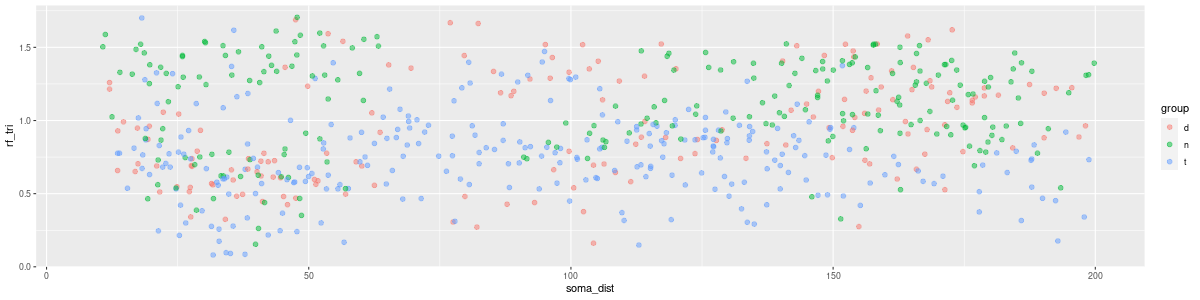

In [14]:
%%R -w 1200 -h 300

p1 <- ggplot(aes(x=soma_dist, y=rf_tri, color=group), data=df)  +
    geom_point(alpha=.5, size=2)

p1

# GAMs

## Noise TRi

In [15]:
%%R

m1  <- gam(rf_tri ~ group + s(soma_dist, k=8, bs="cr"), data=df)
m2  <- gam(rf_tri ~ group + s(soma_dist, by=group, k=8, bs="cr"), data=df)
m3a <- gam(rf_tri ~ group + s(soma_dist, by=group, k=8, bs="cr") + s(cell_id, bs="re"), data=df)
m3b <- gam(rf_tri ~ group + s(soma_dist, by=group, k=8, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')
m4a <- gam(rf_tri ~ group + s(soma_dist, by=group, k=12, bs="cr") + s(cell_id, bs="re"), data=df)
m4b <- gam(rf_tri ~ group + s(soma_dist, by=group, k=12, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')
m5a <- gam(rf_tri ~ group + s(soma_dist, by=group, k=16, bs="cr") + s(cell_id, bs="re"), data=df)
m5b <- gam(rf_tri ~ group + s(soma_dist, by=group, k=16, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')

In [16]:
%%R
BIC(m1, m2, m3a, m3b, m4a, m4b, m5a, m5b)

          df      BIC
m1  10.66565 364.6326
m2  22.59021 401.2657
m3a 35.44732 261.3915
m3b 33.72064 262.8983
m4a 35.23709 256.9904
m4b 37.08006 271.1298
m5a 35.38635 258.7146
m5b 37.57276 275.0347


In [17]:
%%R
anova(m1, m2, m3a, m4a, m5a, test="F")

Analysis of Deviance Table

Model 1: rf_tri ~ group + s(soma_dist, k = 8, bs = "cr")
Model 2: rf_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr")
Model 3: rf_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr") + 
    s(cell_id, bs = "re")
Model 4: rf_tri ~ group + s(soma_dist, by = group, k = 12, bs = "cr") + 
    s(cell_id, bs = "re")
Model 5: rf_tri ~ group + s(soma_dist, by = group, k = 16, bs = "cr") + 
    s(cell_id, bs = "re")
  Resid. Df Resid. Dev       Df Deviance       F    Pr(>F)    
1    642.04     60.064                                        
2    628.77     56.435 13.27165   3.6295  4.2293 6.886e-07 ***
3    615.09     40.076 13.67570  16.3591 18.4996 < 2.2e-16 ***
4    613.82     39.889  1.27714   0.1863  2.2565    0.1263    
5    613.10     39.936  0.72119  -0.0463                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [18]:
%%R
anova(m3b, m4b, m5b, test="F")

Analysis of Deviance Table

Model 1: rf_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr") + 
    s(cell_id, bs = "re")
Model 2: rf_tri ~ group + s(soma_dist, by = group, k = 12, bs = "cr") + 
    s(cell_id, bs = "re")
Model 3: rf_tri ~ group + s(soma_dist, by = group, k = 16, bs = "cr") + 
    s(cell_id, bs = "re")
  Resid. Df Resid. Dev      Df Deviance Pr(>Chi)  
1    617.27     44.387                            
2    613.02     30.849 4.24658  13.5377  0.01087 *
3    612.20     31.562 0.82258  -0.7122           
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



Family: Scaled t(17.62,0.242) 
Link function: identity 

Formula:
rf_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr") + 
    s(cell_id, bs = "re")

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.84380    0.09889   8.533   <2e-16 ***
groupn       0.19531    0.13390   1.459    0.145    
groupt      -0.11405    0.13311  -0.857    0.392    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                       edf Ref.df Chi.sq  p-value    
s(soma_dist):groupd  2.479  3.100  36.65  < 2e-16 ***
s(soma_dist):groupn  5.229  6.059  24.87 0.000596 ***
s(soma_dist):groupt  4.766  5.629  19.96 0.004968 ** 
s(cell_id)          13.234 14.000 263.60  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.469   Deviance explained = 47.7%
-REML =  83.44  Scale est. = 1         n = 652

Method: REML   Optimizer: outer newton
full convergence after

In addition: Warning message:
In getOption("jupyter.base_display_func")(data, metadata) :
  IRdisplay can only be used from the IPython R kernel and R magic.


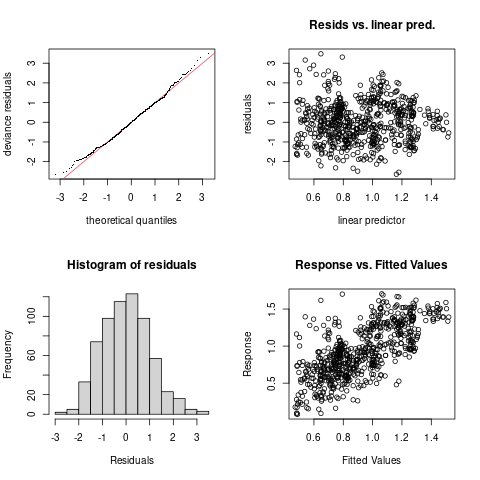

In [19]:
%%R
m <- m3b
display_model(m)
gam.check(m)

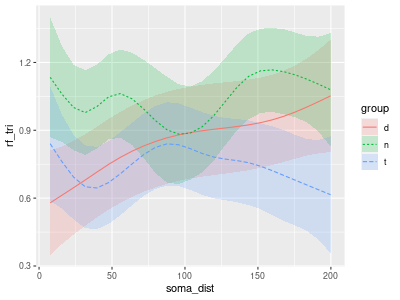

In [20]:
%%R -w 400 -h 300

p1 <- plot_smooths(model=m, series=soma_dist, comparison=group)
plot(p1, ylim=c(0, 60))

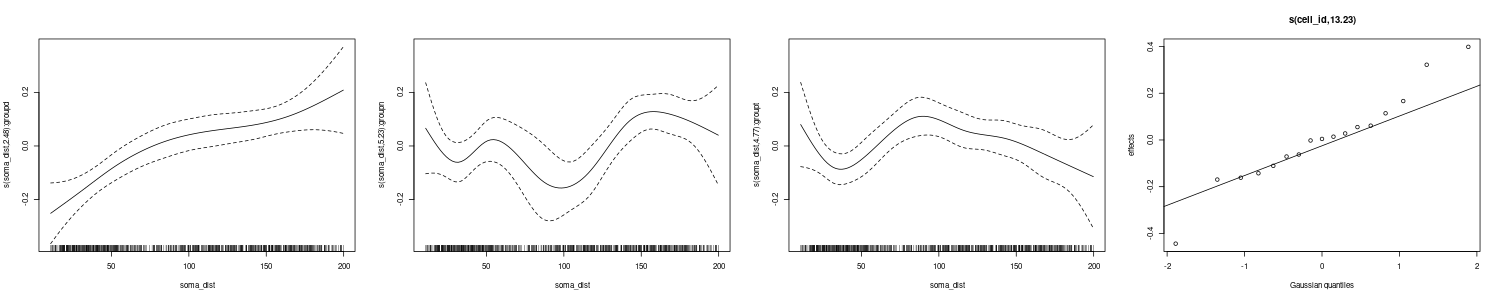

In [21]:
%%R -w 1500 -h 300
par(mfrow = c(1,4))
plot(m)

### Plot fits

In [22]:
%%R

r_df_pred = predict_gam(m, exclude_terms=s(cell_id, bs="re"))
head(r_df_pred)

# A tibble: 6 x 5
  group soma_dist cell_id        fit se.fit
  <fct>     <dbl> <fct>        <dbl>  <dbl>
1 d          7.62 2018-06-10_1 0.579  0.118
2 n          7.62 2018-06-10_1 1.13   0.135
3 t          7.62 2018-06-10_1 0.841  0.129
4 d         11.5  2018-06-10_1 0.596  0.114
5 n         11.5  2018-06-10_1 1.10   0.120
6 t         11.5  2018-06-10_1 0.802  0.117


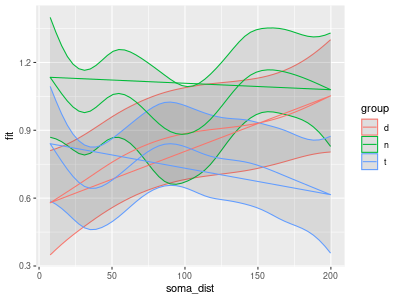

In [23]:
%%R -w 400 -h 300

predict_gam(m, exclude_terms=s(cell_id, bs="re")) %>%
    ggplot(aes(soma_dist, fit, col=group)) +
    geom_smooth_ci()

### Plot differences 

[1] 0.9916667
[1] 2.39398
Summary:
	* soma_dist : numeric predictor; with 100 values ranging from 10.734400 to 199.793000. 
	* cell_id : factor; set to the value(s): 2020-05-10_1. (Might be canceled as random effect, check below.) 
	* NOTE : The following random effects columns are canceled: s(cell_id)
 

soma_dist window(s) of significant difference(s):
	10.734400 - 24.102180
Summary:
	* soma_dist : numeric predictor; with 100 values ranging from 10.734400 to 199.793000. 
	* cell_id : factor; set to the value(s): 2020-05-10_1. (Might be canceled as random effect, check below.) 
	* NOTE : The following random effects columns are canceled: s(cell_id)
 

soma_dist window(s) of significant difference(s):
	29.831228 - 58.476471
	136.773467 - 199.793000
Summary:
	* soma_dist : numeric predictor; with 100 values ranging from 10.734400 to 199.793000. 
	* cell_id : factor; set to the value(s): 2020-05-10_1. (Might be canceled as random effect, check below.) 
	* NOTE : The following random effe

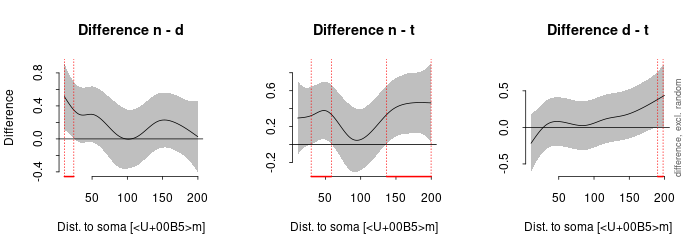

In [24]:
%%R -w 700 -h 250 -o nd_diff -o nt_diff -o dt_diff

#pdf("./figures/rf_size_differences.pdf", width=7, height=3)
n_diffs <- 3
par(mfrow=c(1, n_diffs), cex=1.0, tcl=-0.2)

se <- qnorm((100 - (2.5/n_diffs))/100)
print((100 - (2.5/n_diffs))/100)
print(se)
ylim <- NULL#c(-150, 150)
ylab <- 'Difference'
xlab <- 'Dist. to soma [µm]'

nd_diff <- plot_diff(m, view="soma_dist", comp=list(group=c("n", "d")), se=se, ylab=ylab, xlab=xlab, ylim=ylim, hide.label=TRUE)
nt_diff <- plot_diff(m, view="soma_dist", comp=list(group=c("n", "t")), se=se, ylab='', xlab=xlab, ylim=ylim, hide.label=TRUE)
dt_diff <- plot_diff(m, view="soma_dist", comp=list(group=c("d", "t")), se=se, ylab='', xlab=xlab, ylim=ylim)
#dev.off()

In [25]:
pairs_sig_regions = [
    ("n vs. d  ", get_sig_intervals(nd_diff)),
    ("n vs. t  ", get_sig_intervals(nt_diff)),
    ("d vs. t  ", get_sig_intervals(dt_diff)),
]
pairs_sig_regions

[0 7]
[]
[ 9 25 65 99]
[]
[93 98]
[]


[('n vs. d  ', [(10.7344, 24.1021797979798)]),
 ('n vs. t  ',
  [(27.921545454545456, 58.47647070707071), (134.86378383838385, 199.793)]),
 ('d vs. t  ', [(188.33490303030302, 197.88331717171718)])]

# Go back to python for easy plotting

In [26]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

with localconverter(ro.default_converter + pandas2ri.converter):
    df_pred = ro.conversion.rpy2py(ro.globalenv['r_df_pred'])

(2.5, 1.8)


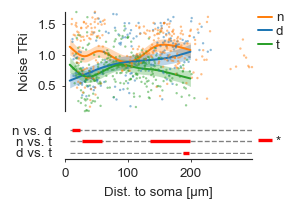

In [27]:
fig, axs = utils.plot_fits(
    df=df,
    df_preds=[df_pred],
    pairs_sig_regions_list=[pairs_sig_regions],
    titles=[None],
    ys=['rf_tri'],
    ylabels=['Noise TRi'],
    x='soma_dist',
    xlabel='Dist. to soma [µm]',
    order=order, colors=colors,
    figsize=(2.5, 1.8), ms=2, ma=0.5
)
plt.tight_layout()
plt.savefig(f'figures/{indicator}_rf_tri_soma_dist.pdf')
plt.show()